In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!head -n 10 datasets/babynames/yob1880.txt

Mary,F,7065
Anna,F,2604
Emma,F,2003
Elizabeth,F,1939
Minnie,F,1746
Margaret,F,1578
Ida,F,1472
Alice,F,1414
Bertha,F,1320
Sarah,F,1288


In [3]:
names1880 = pd.read_csv('datasets/babynames/yob1880.txt', names=['name', 'sex', 'births'])

In [4]:
names1880.groupby('sex')['births'].sum()

sex
F     90993
M    110493
Name: births, dtype: int64

In [5]:
pieces = []
for year in range(1880, 2011):
    path = f'datasets/babynames/yob{year}.txt'
    df = pd.read_csv(path, names=['name', 'sex', 'births'])
    df['year'] = year
    pieces.append(df)

names = pd.concat(pieces, ignore_index=True)

In [6]:
total_births = names.pivot_table('births', index='year', columns = 'sex', aggfunc='sum')

<Axes: title={'center': 'Total births by sex and year'}, xlabel='year'>

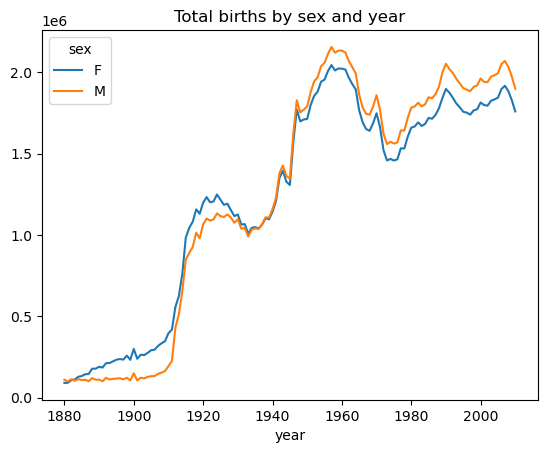

In [7]:
total_births.plot(title="Total births by sex and year")

In [8]:
def add_prop(group):
    group['prop'] = group['births'] / group['births'].sum()
    return group

names = names.groupby(['year', 'sex'], group_keys=False).apply(add_prop)

/var/folders/z3/nzm0k2356c36ngsc80whg_q40000gp/T/ipykernel_92728/410521483.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(['year', 'sex'], group_keys=False).apply(add_prop)


In [9]:
names.groupby(['year', 'sex'])['prop'].sum().reset_index()

,year,sex,prop
0,1880,F,1.0
1,1880,M,1.0
2,1881,F,1.0
3,1881,M,1.0
4,1882,F,1.0
...,...,...,...
257,2008,M,1.0
258,2009,F,1.0
259,2009,M,1.0
260,2010,F,1.0


In [10]:
def get_top1000(group):
    return group.sort_values(by='births', ascending=False).head(1000)

grouped = names.groupby(['year', 'sex'])
top1000 = grouped.apply(get_top1000).reset_index(drop=True)
top1000

/var/folders/z3/nzm0k2356c36ngsc80whg_q40000gp/T/ipykernel_92728/1136320184.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = grouped.apply(get_top1000).reset_index(drop=True)


,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077643
1,Anna,F,2604,1880,0.028618
2,Emma,F,2003,1880,0.022013
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
261872,Camilo,M,194,2010,0.000102
261873,Destin,M,194,2010,0.000102
261874,Jaquan,M,194,2010,0.000102
261875,Jaydan,M,194,2010,0.000102


In [11]:
#name trends for specific names
boys = top1000.query('sex == "M"')
girls = top1000.query('sex == "F"')

In [12]:
total_births = top1000.pivot_table(
    values = 'births',
    index = 'year',
    columns = 'name',
    aggfunc = 'sum',
)

In [13]:
total_births.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6868 entries, Aaden to Zuri
dtypes: float64(6868)
memory usage: 6.9 MB


In [14]:
subset = total_births[['John', 'Harry', 'Mary', 'Marilyn']]

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>, <Axes: xlabel='year'>], dtype=object)

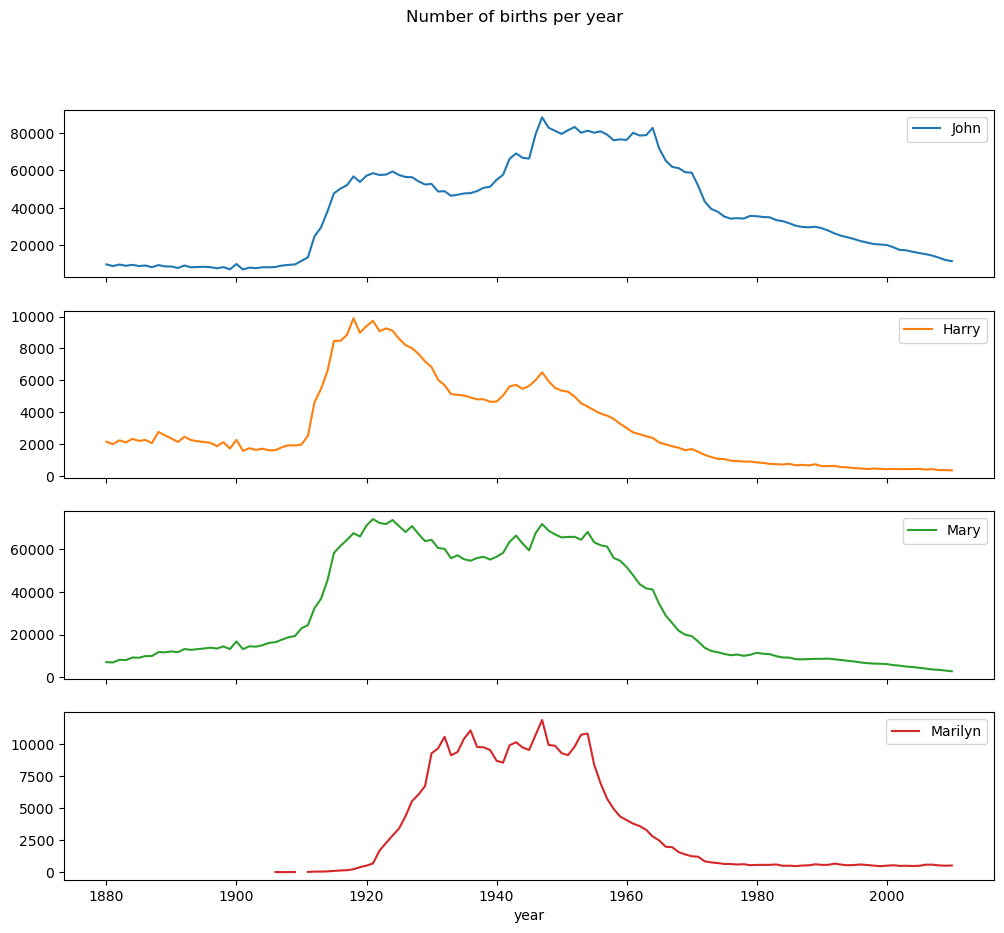

In [15]:
subset.plot(subplots=True, figsize=(12, 10), grid=False, title="Number of births per year")

In [16]:
# increase of name diversity
table = top1000.pivot_table(
    values = 'prop',
    index = 'year',
    columns = 'sex',
    aggfunc = 'sum',
)

<Axes: title={'center': 'Sum of table1000.prop by year and sex'}, xlabel='year'>

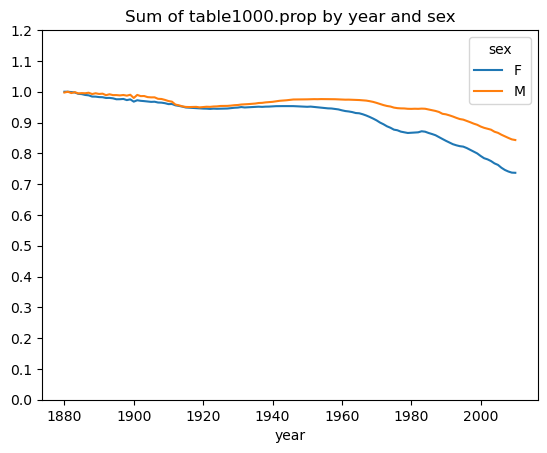

In [17]:
table.plot(title="Sum of table1000.prop by year and sex",
           yticks = np.linspace(0, 1.2, 13))

In [18]:
#number of distint names
def get_quantile_count(group, q=0.5):
    group = group.sort_values(by='prop', ascending=False)
    return group['prop'].cumsum().searchsorted(q) + 1

diveristy = top1000.groupby(['year', 'sex']).apply(get_quantile_count).unstack()

/var/folders/z3/nzm0k2356c36ngsc80whg_q40000gp/T/ipykernel_92728/2933573341.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diveristy = top1000.groupby(['year', 'sex']).apply(get_quantile_count).unstack()


<Axes: title={'center': 'Number of popular names in top 50%'}, xlabel='year'>

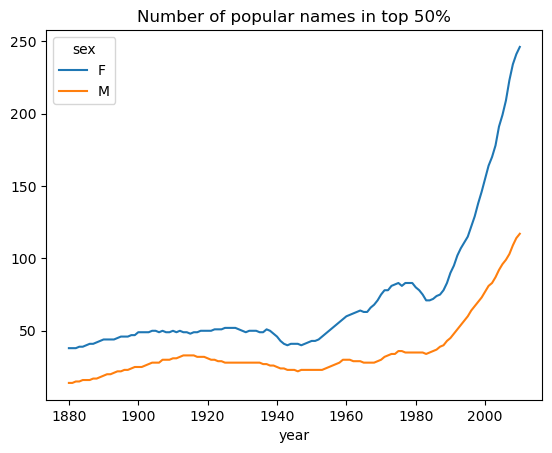

In [19]:
diveristy.plot(title="Number of popular names in top 50%")

In [20]:
# the last letter problem
def get_last_letter(name):
    return name[-1]

In [24]:
last_letters = names['name'].map(get_last_letter)
last_letters.name = 'last_letter'

In [26]:
table = names.pivot_table(
    values = 'births',
    index = last_letters,
    columns = ['sex','year'],
    aggfunc = 'sum',
)

In [27]:
subtable = table.reindex(columns=[1910, 1960, 2010], level='year')

In [29]:
subtable.sum()

sex  year
F    1910     396416.0
     1960    2022062.0
     2010    1759010.0
M    1910     194198.0
     1960    2132588.0
     2010    1898382.0
dtype: float64

In [31]:
letter_prop = subtable / subtable.sum()

<Axes: title={'center': 'Female'}, xlabel='last_letter'>

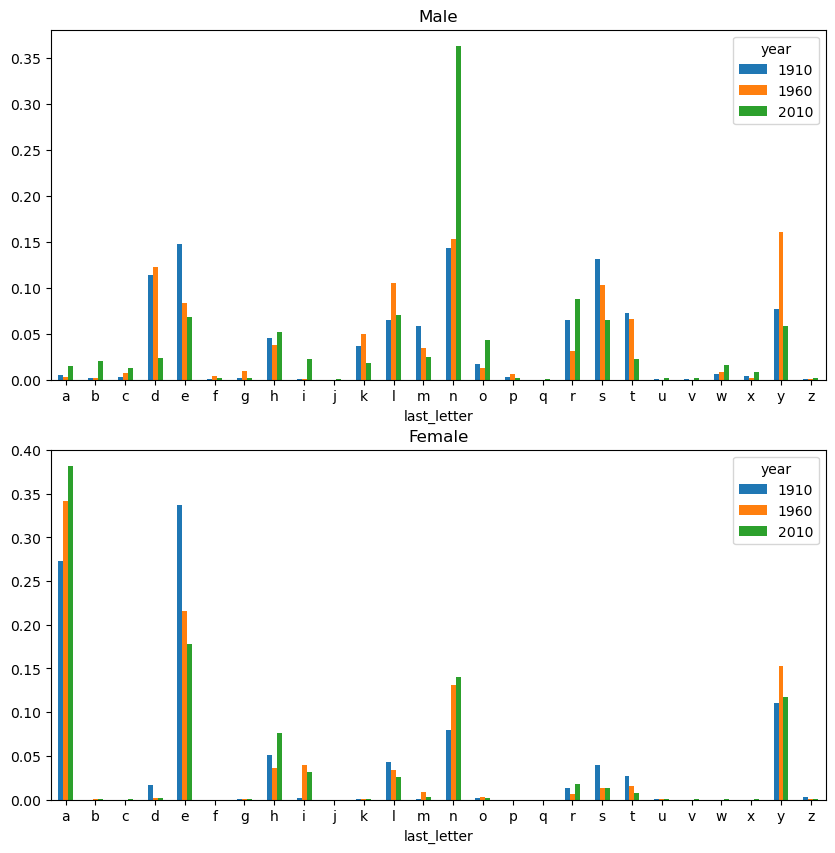

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
letter_prop['M'].plot(kind='bar', rot=0, ax=axes[0], title='Male')
letter_prop['F'].plot(kind='bar', rot=0, ax=axes[1], title='Female')

In [38]:
letter_prop = table/ table.sum()

In [47]:
# Select the data for the year 1880 for all sexes
dny_ts = letter_prop.loc[['d', 'n', 'y'], 'M'].T

<Axes: xlabel='year'>

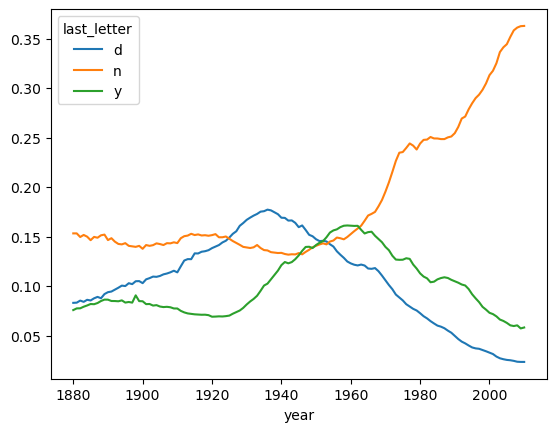

In [48]:
dny_ts.plot()

In [53]:
#Boy names that became girl names (and vice versa)
all_names = pd.Series(top1000['name'].unique())

In [54]:
lesley_like = all_names[all_names.str.contains('Lesl')]

In [55]:
filtered = top1000[top1000['name'].isin(lesley_like)]

In [56]:
filtered.groupby('name').births.sum()

name
Leslee      1082
Lesley     35022
Lesli        929
Leslie    370429
Lesly      10067
Name: births, dtype: int64

In [57]:
table = filtered.pivot_table(
    values = 'births',
    index = 'year',
    columns = 'sex',
    aggfunc = 'sum',
)

In [65]:
table = table.div(table.sum(axis=1), axis=0)

<Axes: title={'center': 'Lesley-like names'}, xlabel='year'>

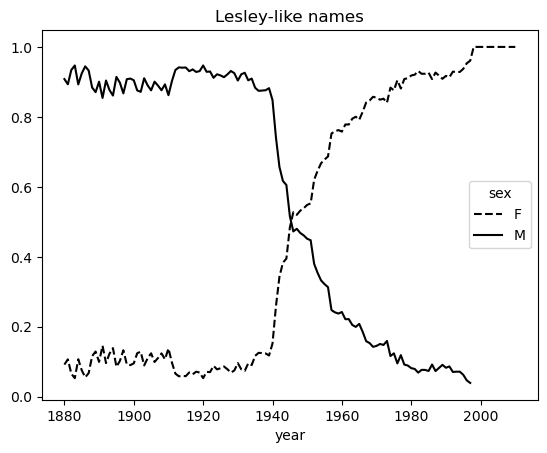

In [66]:
table.plot(title="Lesley-like names",
           style = {'M': 'k-', 'F': 'k--'})